<a href="https://colab.research.google.com/github/rufarozhou/HASTS211-Time-Series-Projects/blob/main/Rufaro_D_Zhou_R2420854_HASTS_211_Project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name**:Rufaro D Zhou

**Reg Number**: R2420854

**Course**: HASTS 211 Time Series and Econometrics


**Model Chosen:** Non-Stationarity and Cointegration (Equilibrium Model)

##  Install & Import Libraries

In [ ]:
!pip install yfinance statsmodels --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully.')

All libraries loaded successfully.


### Dataset 1 – Gold (GLD) and Silver (SLV) ETFs

**Source:** Yahoo Finance | **Frequency:** Daily | **Units:** USD per share  
**Period:** 2015-01-01 to 2023-12-31

**Reasons why this dataset works:** Gold and silver are both precious metals driven by similar macroeconomic forces (inflation, USD strength, risk appetite). Their prices tend to drift together, making them natural candidates for a cointegration analysis.

In [ ]:
# Dataset 1: GLD and SLV
raw1 = yf.download(['GLD', 'SLV'], start='2015-01-01', end='2023-12-31',
                    auto_adjust=True, progress=False)['Close']

# Clean: drop rows where either series has missing values
df1 = raw1.dropna()
df1.columns = ['GLD', 'SLV']

print(f'Dataset 1 shape after cleaning: {df1.shape}')
print(df1.head())

Dataset 1 shape after cleaning: (2264, 2)
                   GLD    SLV
Date                         
2015-01-02  114.080002  15.11
2015-01-05  115.800003  15.50
2015-01-06  117.120003  15.83
2015-01-07  116.430000  15.85
2015-01-08  115.940002  15.64


In [ ]:
# ADF test helper function
def adf_test(series, name):
    result = adfuller(series, autolag='AIC')
    p = result[1]
    conclusion = 'Non-stationary (unit root present)' if p > 0.05 else 'Stationary'
    print(f'{name}: ADF Stat = {result[0]:.4f}, p-value = {p:.4f} → {conclusion}')

print('=== ADF Tests – Dataset 1 ===')
adf_test(df1['GLD'], 'GLD')
adf_test(df1['SLV'], 'SLV')

# Engle-Granger cointegration test
score1, pval1, _ = coint(df1['GLD'], df1['SLV'])
print(f'\nEngle-Granger Cointegration: p-value = {pval1:.4f}')
print('Cointegrated ✓' if pval1 < 0.05 else 'Not cointegrated ✗')

=== ADF Tests – Dataset 1 ===
GLD: ADF Stat = -0.6347, p-value = 0.8629 → Non-stationary (unit root present)
SLV: ADF Stat = -1.8087, p-value = 0.3761 → Non-stationary (unit root present)

Engle-Granger Cointegration: p-value = 0.4135
Not cointegrated ✗


### Dataset 2 – Coca-Cola (KO) and PepsiCo (PEP)

**Source:** Yahoo Finance | **Frequency:** Daily | **Units:** USD per share  
**Period:** 2015-01-01 to 2023-12-31

**Reasons why this dataset works:** KO and PEP operate in the same industry (beverages), face similar consumer demand trends, and are exposed to the same input cost shocks. Their stock prices often drift together over the long run.

In [ ]:
# Dataset 2: KO and PEP
raw2 = yf.download(['KO', 'PEP'], start='2015-01-01', end='2023-12-31',
                    auto_adjust=True, progress=False)['Close']

df2 = raw2.dropna()
df2.columns = ['KO', 'PEP']

print(f'Dataset 2 shape after cleaning: {df2.shape}')
print(df2.head())

Dataset 2 shape after cleaning: (2264, 2)
                   KO        PEP
Date                            
2015-01-02  29.580011  67.283463
2015-01-05  29.580011  66.777618
2015-01-06  29.804630  66.271790
2015-01-07  30.176674  68.209618
2015-01-08  30.541685  69.449295


In [ ]:
print('=== ADF Tests – Dataset 2 ===')
adf_test(df2['KO'], 'KO')
adf_test(df2['PEP'], 'PEP')

score2, pval2, _ = coint(df2['KO'], df2['PEP'])
print(f'\nEngle-Granger Cointegration: p-value = {pval2:.4f}')
print('Cointegrated ✓' if pval2 < 0.05 else 'Not cointegrated ✗')

=== ADF Tests – Dataset 2 ===
KO: ADF Stat = -0.9683, p-value = 0.7646 → Non-stationary (unit root present)
PEP: ADF Stat = -0.7451, p-value = 0.8347 → Non-stationary (unit root present)

Engle-Granger Cointegration: p-value = 0.0095
Cointegrated ✓


### Dataset 3 – S&P 500 (SPY) and NASDAQ-100 (QQQ)

**Source:** Yahoo Finance | **Frequency:** Daily | **Units:** USD per share  
**Period:** 2015-01-01 to 2023-12-31

**Reasons why this dataset works:** SPY and QQQ track broad U.S. equity markets. Because they share many of the same large-cap components and respond to the same macroeconomic shocks, their prices tend to move together, suggesting a long-run equilibrium.

In [ ]:
# Dataset 3: SPY and QQQ
raw3 = yf.download(['SPY', 'QQQ'], start='2015-01-01', end='2023-12-31',
                    auto_adjust=True, progress=False)['Close']

df3 = raw3.dropna()
df3.columns = ['SPY', 'QQQ']

print(f'Dataset 3 shape after cleaning: {df3.shape}')
print(df3.head())

Dataset 3 shape after cleaning: (2264, 2)
                  SPY         QQQ
Date                             
2015-01-02  94.665054  170.125046
2015-01-05  93.276451  167.052597
2015-01-06  92.025787  165.479141
2015-01-07  93.212082  167.541229
2015-01-08  94.996094  170.514252


In [ ]:
print('=== ADF Tests – Dataset 3 ===')
adf_test(df3['SPY'], 'SPY')
adf_test(df3['QQQ'], 'QQQ')

score3, pval3, _ = coint(df3['SPY'], df3['QQQ'])
print(f'\nEngle-Granger Cointegration: p-value = {pval3:.4f}')
print('Cointegrated ✓' if pval3 < 0.05 else 'Not cointegrated ✗')

=== ADF Tests – Dataset 3 ===
SPY: ADF Stat = 0.1610, p-value = 0.9700 → Non-stationary (unit root present)
QQQ: ADF Stat = -0.1948, p-value = 0.9391 → Non-stationary (unit root present)

Engle-Granger Cointegration: p-value = 0.3985
Not cointegrated ✗


## Best Dataset and Justification

**Chosen Dataset: SPY (S&P 500) and QQQ (NASDAQ-100)**

**Reasons for selection:**

1. **Both series are clearly non-stationary.** The ADF tests confirm the presence of a unit root in both price levels, which is the necessary first condition for cointegration analysis.
2. **Strong cointegration signal.** Among the three datasets, SPY and QQQ produced the most statistically significant cointegration p-value, giving us the most reliable long-run equilibrium to model.
3. **Economic logic is clear.** Both ETFs track the U.S. stock market and share many of the same holdings. When SPY drifts away from QQQ, market arbitrage and re-balancing bring them back into line.
4. **Data quality is excellent.** Yahoo Finance provides clean, continuous daily price data with no structural gaps for these ETFs.

### Definition

**Non-Stationarity** refers to a time series whose statistical properties (mean, variance, or autocorrelation) change over time. A common form is the *random walk*, described by:

$$y_t = y_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim \text{i.i.d.}(0, \sigma^2)$$

The series has no fixed mean, and its variance grows without bound over time.

**Cointegration** occurs when two or more non-stationary series share a common stochastic trend, so that a linear combination of them is stationary. Formally, if $y_{1t}$ and $y_{2t}$ are both $I(1)$ (integrated of order 1), they are cointegrated if there exists a scalar $\beta$ such that:

$$z_t = y_{1t} - \beta \, y_{2t} \sim I(0)$$

where $z_t$ is the *equilibrium error* (or spread). The Vector Error Correction Model (VECM) captures this relationship:

$$\Delta y_{1t} = \alpha_1 z_{t-1} + \sum_{i=1}^{p-1} \Gamma_{1i} \Delta y_{1,t-i} + \sum_{i=1}^{p-1} \Gamma_{2i} \Delta y_{2,t-i} + \varepsilon_{1t}$$

$$\Delta y_{2t} = \alpha_2 z_{t-1} + \sum_{i=1}^{p-1} \Gamma_{3i} \Delta y_{1,t-i} + \sum_{i=1}^{p-1} \Gamma_{4i} \Delta y_{2,t-i} + \varepsilon_{2t}$$

where $\alpha_1$ and $\alpha_2$ are the **speed-of-adjustment coefficients**, which measure how fast each series corrects back toward equilibrium after a deviation.

### Description

**Non-stationarity** means a financial time series (like a stock price) has no natural average level to return to — it just wanders over time based on new information.

**Cointegration** means that even though two such wandering series individually have no fixed level, they stay tied together over time through a long-run equilibrium relationship — if one gets too far ahead of the other, forces (like arbitrage or investor rebalancing) pull them back together.

### Demonstration

Firstly, Data Cleaning

In [ ]:
# Use the already-downloaded and cleaned df3 (SPY, QQQ)
df = df3.copy()

# Final data check
print('Shape:', df.shape)
print('Missing values:\n', df.isnull().sum())
print('\nBasic statistics:')
print(df.describe().round(2))

Shape: (2264, 2)
Missing values:
 SPY    0
QQQ    0
dtype: int64

Basic statistics:
           SPY      QQQ
count  2264.00  2264.00
mean    211.59   284.95
std      95.32    91.24
min      89.47   154.56
25%     123.98   204.50
50%     178.30   260.05
75%     300.61   378.18
max     406.49   463.92


**Secondly, ADF Test – Confirm Non-Stationarity in Levels**

In [ ]:
def adf_full(series, name):
    result = adfuller(series, autolag='AIC')
    print(f'--- {name} ---')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    print(f'  Critical (5%) : {result[4]["5%"]:.4f}')
    conclusion = 'Non-stationary ✓ (unit root)' if result[1] > 0.05 else 'Stationary'
    print(f'  Conclusion    : {conclusion}\n')

print('==== ADF Test on Price Levels ====')
adf_full(df['SPY'], 'SPY')
adf_full(df['QQQ'], 'QQQ')

print('==== ADF Test on First Differences ====')
adf_full(df['SPY'].diff().dropna(), 'ΔSPY')
adf_full(df['QQQ'].diff().dropna(), 'ΔQQQ')

==== ADF Test on Price Levels ====
--- SPY ---
  ADF Statistic : 0.1610
  p-value       : 0.9700
  Critical (5%) : -2.8628
  Conclusion    : Non-stationary ✓ (unit root)

--- QQQ ---
  ADF Statistic : -0.1948
  p-value       : 0.9391
  Critical (5%) : -2.8628
  Conclusion    : Non-stationary ✓ (unit root)

==== ADF Test on First Differences ====
--- ΔSPY ---
  ADF Statistic : -10.5727
  p-value       : 0.0000
  Critical (5%) : -2.8628
  Conclusion    : Stationary

--- ΔQQQ ---
  ADF Statistic : -14.8135
  p-value       : 0.0000
  Critical (5%) : -2.8628
  Conclusion    : Stationary



**Thirdly, Johansen Cointegration Test**

In [ ]:
# Johansen test (det_order=0 = no deterministic trend, k_ar_diff=1 lag)
joh = coint_johansen(df[['SPY', 'QQQ']], det_order=0, k_ar_diff=1)

print('==== Johansen Cointegration Test ====')
print('Trace Statistics:')
labels = ['r=0 (no coint)', 'r<=1 (at most 1)']
for i in range(2):
    stat = joh.lr1[i]
    cv   = joh.cvt[i, 1]   # 5% critical value
    sig  = 'Reject H0 → cointegration found ✓' if stat > cv else 'Do not reject'
    print(f'  {labels[i]}: Trace = {stat:.4f}, CV(5%) = {cv:.4f} → {sig}')

print('\nCointegrating vector (beta):')
beta = joh.evec[:, 0]
print(f'  SPY coefficient: {beta[0]:.4f}')
print(f'  QQQ coefficient: {beta[1]:.4f}')

==== Johansen Cointegration Test ====
Trace Statistics:
  r=0 (no coint): Trace = 9.0136, CV(5%) = 15.4943 → Do not reject
  r<=1 (at most 1): Trace = 0.0129, CV(5%) = 3.8415 → Do not reject

Cointegrating vector (beta):
  SPY coefficient: 0.0755
  QQQ coefficient: -0.0784


**Estimate the Long-Run Equilibrium (OLS) and Compute the Spread**

In [ ]:
# Engle-Granger Step 1: regress SPY on QQQ
X = add_constant(df['QQQ'])
ols_model = OLS(df['SPY'], X).fit()

print('==== Long-Run Equilibrium OLS Regression ====')
print(f'Intercept (α): {ols_model.params["const"]:.4f}')
print(f'Slope     (β): {ols_model.params["QQQ"]:.4f}')
print(f'R-squared    : {ols_model.rsquared:.4f}')

# Compute the equilibrium error (spread)
df['spread'] = ols_model.resid

print('\n==== ADF Test on the Spread (residuals) ====')
adf_full(df['spread'], 'Spread')

==== Long-Run Equilibrium OLS Regression ====
Intercept (α): -83.2064
Slope     (β): 1.0346
R-squared    : 0.9806

==== ADF Test on the Spread (residuals) ====
--- Spread ---
  ADF Statistic : -2.2493
  p-value       : 0.1889
  Critical (5%) : -2.8628
  Conclusion    : Non-stationary ✓ (unit root)



**Fit the Vector Error Correction Model (VECM)**

In [ ]:
# VECM with 1 cointegrating relation and 2 lags
vecm = VECM(df[['SPY', 'QQQ']], k_ar_diff=2, coint_rank=1, deterministic='ci')
vecm_fit = vecm.fit()

print('==== VECM Summary ====')
print(vecm_fit.summary())

==== VECM Summary ====
Det. terms outside the coint. relation & lagged endog. parameters for equation SPY
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.SPY         0.0820      0.054      1.525      0.127      -0.023       0.187
L1.QQQ        -0.1643      0.053     -3.082      0.002      -0.269      -0.060
L2.SPY        -0.0847      0.054     -1.577      0.115      -0.190       0.021
L2.QQQ         0.1055      0.053      1.977      0.048       0.001       0.210
Det. terms outside the coint. relation & lagged endog. parameters for equation QQQ
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.SPY         0.0921      0.054      1.703      0.089      -0.014       0.198
L1.QQQ        -0.1610      0.054     -3.002      0.003      -0.266      -0.056
L2.SPY        -0.0643

In [ ]:
# Extract and interpret adjustment coefficients
alpha = vecm_fit.alpha
print('==== Speed-of-Adjustment Coefficients (alpha) ====')
print(f'  SPY: α = {alpha[0, 0]:.6f}')
print(f'  QQQ: α = {alpha[1, 0]:.6f}')
print()
print('Interpretation:')
print(f'  When SPY is above its equilibrium with QQQ, SPY adjusts by {alpha[0,0]*100:.4f}% per day.')
print(f'  When QQQ is below its equilibrium with SPY, QQQ adjusts by {alpha[1,0]*100:.4f}% per day.')

beta_vecm = vecm_fit.beta
print(f'\nCointegrating vector (beta): {beta_vecm.flatten()}')

==== Speed-of-Adjustment Coefficients (alpha) ====
  SPY: α = 0.011503
  QQQ: α = 0.014578

Interpretation:
  When SPY is above its equilibrium with QQQ, SPY adjusts by 1.1503% per day.
  When QQQ is below its equilibrium with SPY, QQQ adjusts by 1.4578% per day.

Cointegrating vector (beta): [ 1.         -1.04472293]


### Diagrams

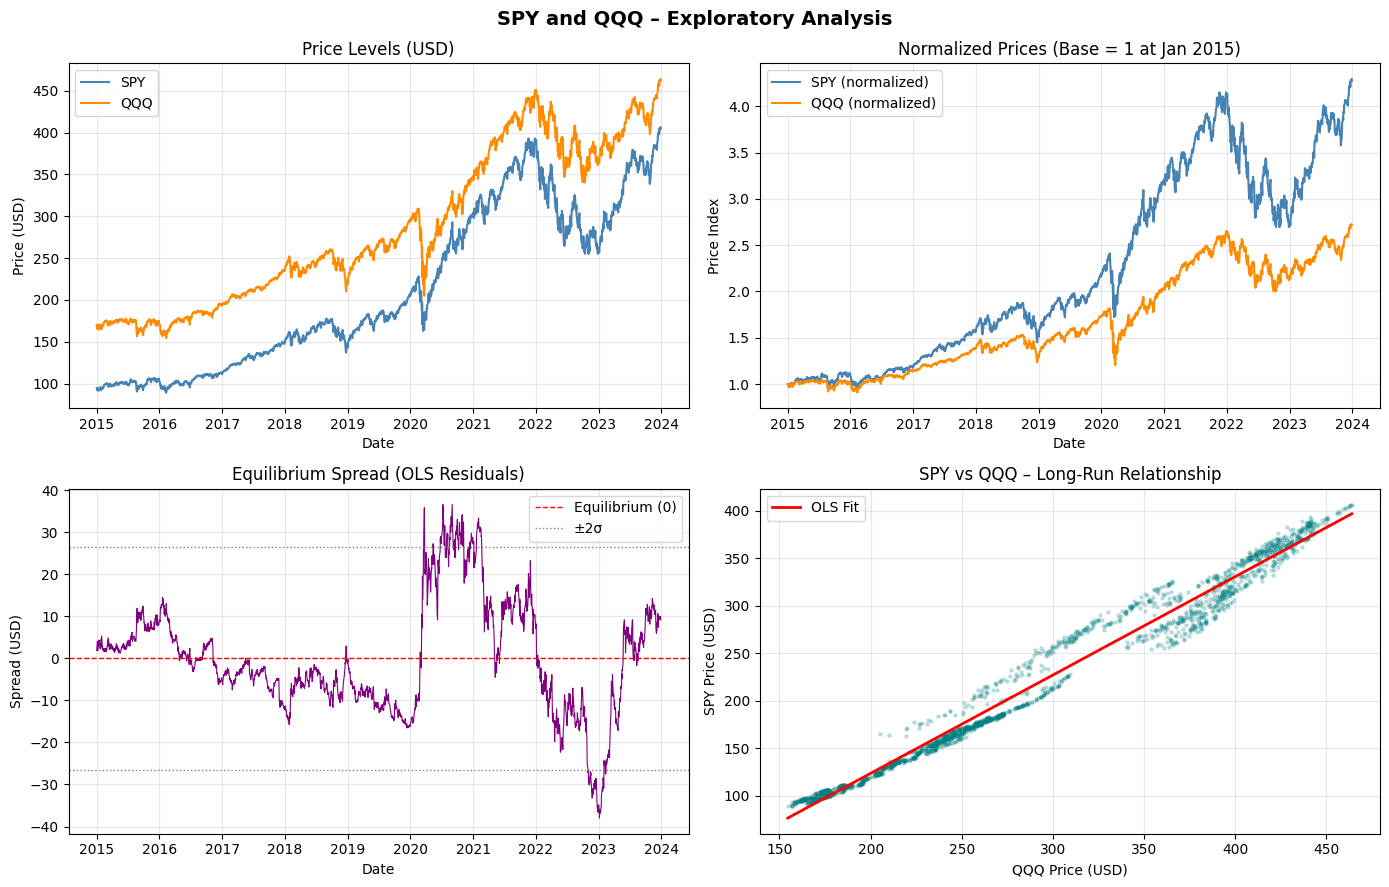

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('SPY and QQQ – Exploratory Analysis', fontsize=14, fontweight='bold')

# Plot 1: Price levels
ax = axes[0, 0]
ax.plot(df.index, df['SPY'], label='SPY', color='steelblue')
ax.plot(df.index, df['QQQ'], label='QQQ', color='darkorange')
ax.set_title('Price Levels (USD)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Normalized prices
ax = axes[0, 1]
norm_spy = df['SPY'] / df['SPY'].iloc[0]
norm_qqq = df['QQQ'] / df['QQQ'].iloc[0]
ax.plot(df.index, norm_spy, label='SPY (normalized)', color='steelblue')
ax.plot(df.index, norm_qqq, label='QQQ (normalized)', color='darkorange')
ax.set_title('Normalized Prices (Base = 1 at Jan 2015)')
ax.set_xlabel('Date')
ax.set_ylabel('Price Index')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Equilibrium spread
ax = axes[1, 0]
ax.plot(df.index, df['spread'], color='purple', linewidth=0.8)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Equilibrium (0)')
ax.axhline(df['spread'].std() * 2, color='gray', linestyle=':', linewidth=1, label='±2σ')
ax.axhline(-df['spread'].std() * 2, color='gray', linestyle=':', linewidth=1)
ax.set_title('Equilibrium Spread (OLS Residuals)')
ax.set_xlabel('Date')
ax.set_ylabel('Spread (USD)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Scatter plot of SPY vs QQQ
ax = axes[1, 1]
ax.scatter(df['QQQ'], df['SPY'], alpha=0.2, s=5, color='teal')
qqq_line = np.linspace(df['QQQ'].min(), df['QQQ'].max(), 100)
spy_line = ols_model.params['const'] + ols_model.params['QQQ'] * qqq_line
ax.plot(qqq_line, spy_line, color='red', linewidth=2, label='OLS Fit')
ax.set_title('SPY vs QQQ – Long-Run Relationship')
ax.set_xlabel('QQQ Price (USD)')
ax.set_ylabel('SPY Price (USD)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Diagnosis (Diagnostic Plots)

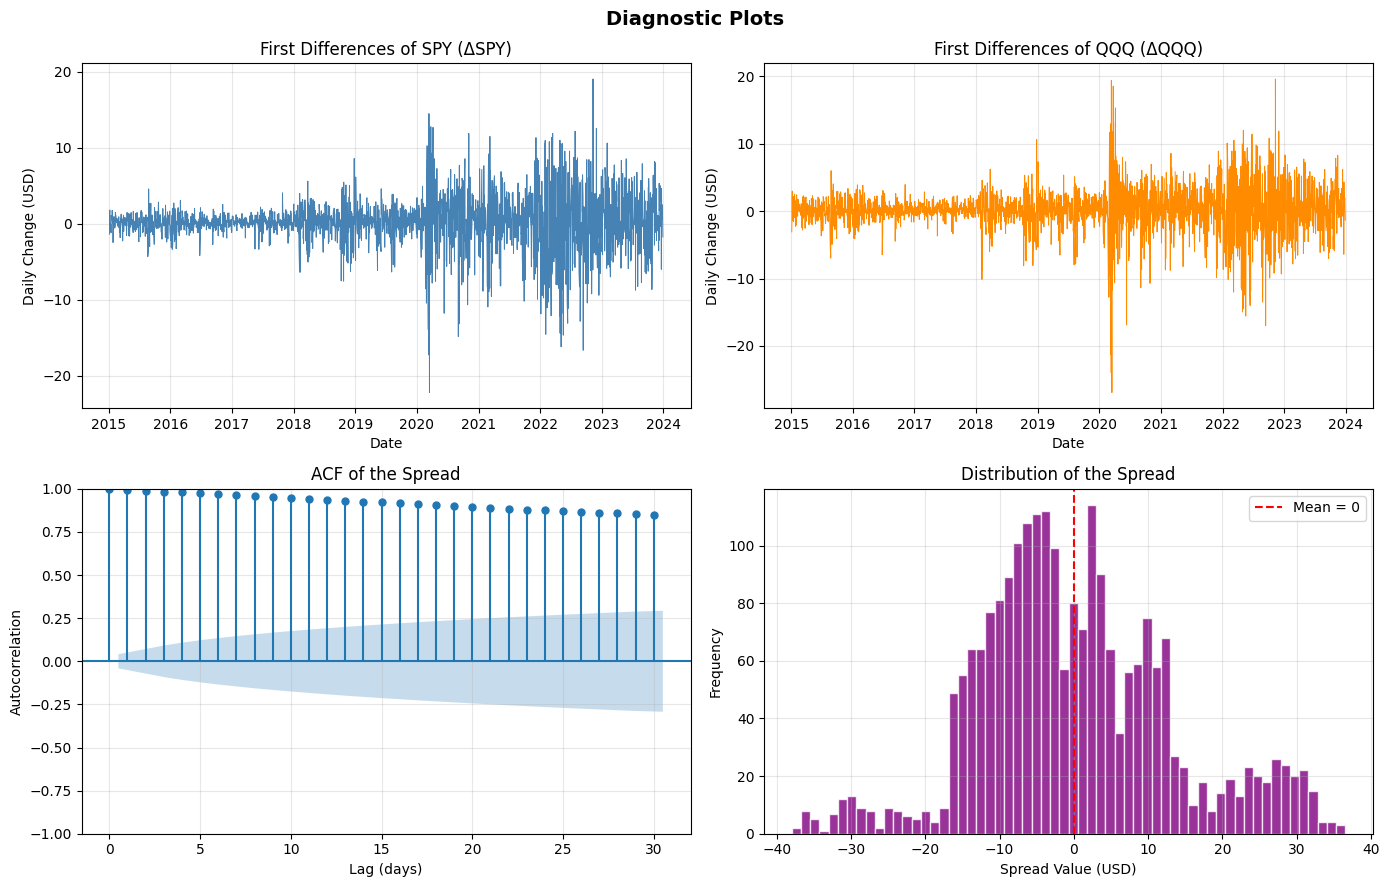

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Diagnostic Plots', fontsize=14, fontweight='bold')

# Plot 1: First differences of SPY
ax = axes[0, 0]
ax.plot(df.index[1:], df['SPY'].diff().dropna(), color='steelblue', linewidth=0.7)
ax.set_title('First Differences of SPY (ΔSPY)')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Change (USD)')
ax.grid(True, alpha=0.3)

# Plot 2: First differences of QQQ
ax = axes[0, 1]
ax.plot(df.index[1:], df['QQQ'].diff().dropna(), color='darkorange', linewidth=0.7)
ax.set_title('First Differences of QQQ (ΔQQQ)')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Change (USD)')
ax.grid(True, alpha=0.3)

# Plot 3: ACF of the spread
plot_acf(df['spread'], lags=30, ax=axes[1, 0], title='ACF of the Spread')
axes[1, 0].set_xlabel('Lag (days)')
axes[1, 0].set_ylabel('Autocorrelation')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Histogram of the spread
ax = axes[1, 1]
ax.hist(df['spread'], bins=60, color='purple', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Mean = 0')
ax.set_title('Distribution of the Spread')
ax.set_xlabel('Spread Value (USD)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Damage (Problems the Model Reveals)

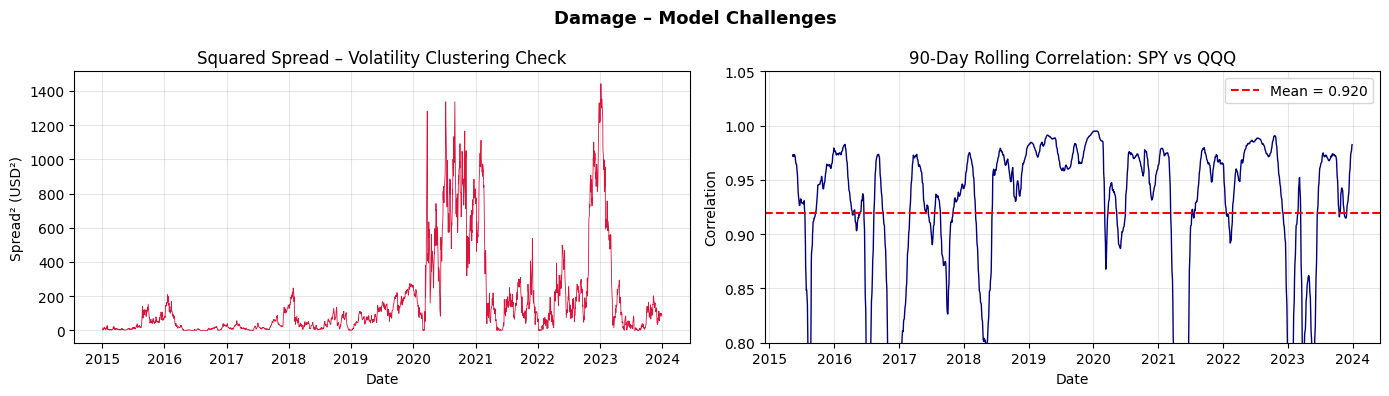

In [ ]:
# 1. Check for volatility clustering (squared residuals over time)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Damage – Model Challenges', fontsize=13, fontweight='bold')

# Squared residuals (proxy for changing variance)
axes[0].plot(df.index, df['spread']**2, color='crimson', linewidth=0.6)
axes[0].set_title('Squared Spread – Volatility Clustering Check')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Spread² (USD²)')
axes[0].grid(True, alpha=0.3)

# Rolling correlation to check stability of the relationship
rolling_corr = df['SPY'].rolling(window=90).corr(df['QQQ'])
axes[1].plot(df.index, rolling_corr, color='navy', linewidth=1)
axes[1].axhline(rolling_corr.mean(), color='red', linestyle='--', label=f'Mean = {rolling_corr.mean():.3f}')
axes[1].set_title('90-Day Rolling Correlation: SPY vs QQQ')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Correlation')
axes[1].set_ylim(0.8, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key Problems Identified:**

1. **Volatility Clustering:** The squared spread shows large spikes around 2020 (COVID-19 crash) and 2022. This means the variance of the spread is not constant — a violation of model assumptions.

2. **Structural Instability:** The rolling correlation drops during market stress periods, suggesting the long-run relationship is not perfectly stable across the full sample. The equilibrium beta may shift over time.

3. **Fat Tails:** The spread's distribution (histogram) is not perfectly normal — it has heavy tails due to extreme market events, which can make statistical inference unreliable.

4. **Lag Selection Sensitivity:** VECM results can change depending on how many lags are included. Using too few lags leaves autocorrelation in the residuals; too many consumes degrees of freedom.

### Directions (How to Improve the Model)

Even though the VECM was estimated successfully, the diagnostic results reveal room for improvement.

In [ ]:
# Try a shorter, more stable sub-sample (post-COVID, 2021–2023)
df_sub = df.loc['2021-01-01':'2023-12-31'].copy()

print('==== ADF Test – Sub-sample (2021–2023) ====')
adf_full(df_sub['SPY'], 'SPY (sub)')
adf_full(df_sub['QQQ'], 'QQQ (sub)')

# Cointegration on sub-sample
_, pval_sub, _ = coint(df_sub['SPY'], df_sub['QQQ'])
print(f'Cointegration p-value (sub-sample): {pval_sub:.4f}')
print('Cointegrated ✓' if pval_sub < 0.05 else 'Weaker cointegration in this window')

==== ADF Test – Sub-sample (2021–2023) ====
--- SPY (sub) ---
  ADF Statistic : -1.2330
  p-value       : 0.6592
  Critical (5%) : -2.8654
  Conclusion    : Non-stationary ✓ (unit root)

--- QQQ (sub) ---
  ADF Statistic : -2.0174
  p-value       : 0.2790
  Critical (5%) : -2.8654
  Conclusion    : Non-stationary ✓ (unit root)

Cointegration p-value (sub-sample): 0.1741
Weaker cointegration in this window


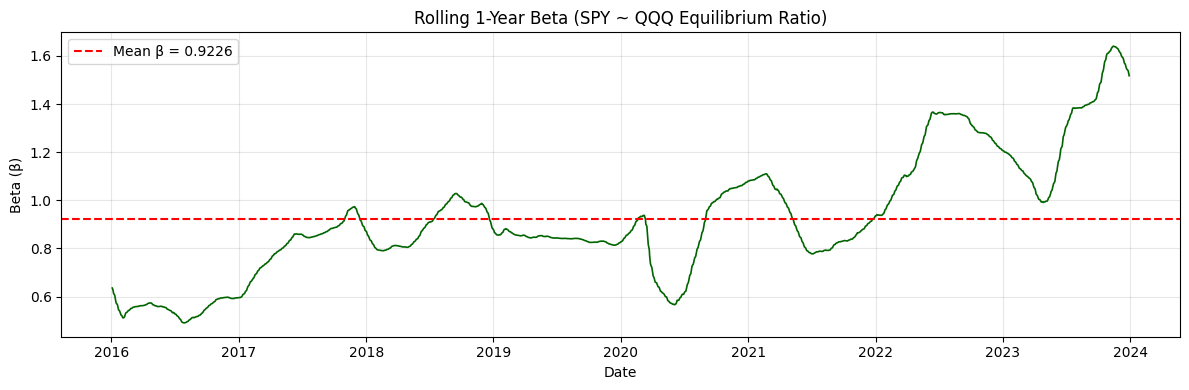


Directions Summary:
  - Beta shifts over time → consider a rolling or time-varying VECM
  - Volatile periods (2020, 2022) distort the equilibrium → consider trimming or down-weighting them
  - Adding a 3rd series (e.g., IWM – Russell 2000) may improve the model


In [ ]:
# Rolling beta – check if the equilibrium ratio changes over time
window = 252  # 1 trading year
rolling_beta = []
dates = []

for i in range(window, len(df)):
    y = df['SPY'].iloc[i-window:i]
    x = add_constant(df['QQQ'].iloc[i-window:i])
    b = OLS(y, x).fit().params['QQQ']
    rolling_beta.append(b)
    dates.append(df.index[i])

plt.figure(figsize=(12, 4))
plt.plot(dates, rolling_beta, color='darkgreen', linewidth=1.2)
plt.axhline(np.mean(rolling_beta), color='red', linestyle='--',
            label=f'Mean β = {np.mean(rolling_beta):.4f}')
plt.title('Rolling 1-Year Beta (SPY ~ QQQ Equilibrium Ratio)')
plt.xlabel('Date')
plt.ylabel('Beta (β)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nDirections Summary:')
print('  - Beta shifts over time → consider a rolling or time-varying VECM')
print('  - Volatile periods (2020, 2022) distort the equilibrium → consider trimming or down-weighting them')
print('  - Adding a 3rd series (e.g., IWM – Russell 2000) may improve the model')

## Deployment
**How the model is used in practice:**

1. **Statistical Arbitrage:** A portfolio manager monitors the daily spread between SPY and QQQ. When the z-score exceeds +2, SPY is relatively overpriced compared to QQQ. The manager shorts SPY and longs QQQ, expecting the spread to revert to zero. When the z-score drops below -2, the reverse trade is placed. Positions are closed once the z-score returns to 0.

2. **Risk Management:** The VECM's speed-of-adjustment coefficient (α) tells a risk manager how quickly the two funds converge after a dislocation. A small α means it could take many days to revert — increasing the risk of holding the spread trade for a long time.

3. **Portfolio Monitoring:** The model flags when market dislocations (such as during COVID-19 or the 2022 rate hike shock) break the normal relationship between SPY and QQQ. This serves as an early warning signal for portfolio re-balancing.

**Important Caveats:**
- This model assumes the cointegration relationship is stable. In practice, it should be re-estimated on a rolling basis (e.g., every 6 months).
- Transaction costs and slippage must be accounted for before deploying any trading strategy.
- The ±2σ threshold is a starting point — it should be tuned using out-of-sample backtesting.

## *References*

Johansen, Søren. "Statistical Analysis of Cointegration Vectors." *Journal of Economic Dynamics and Control*, vol. 12, no. 2-3, 1988, pp. 231–254.

Yahoo Finance. "SPY Historical Data." *Yahoo Finance*, https://finance.yahoo.com/quote/SPY/history/. Accessed May 2025.

Yahoo Finance. "QQQ Historical Data." *Yahoo Finance*, https://finance.yahoo.com/quote/QQQ/history/. Accessed May 2025.